Labels

In [2]:
import json
import numpy as np
from pathlib import Path

def infer_global_translation(frames):
    """
    Heuristic:
    If points have small XY spread but frame positions have larger XY spread,
    assume points are local offsets that should be translated by frame.position.
    """
    pos_xy = np.array([[f["position"].get("x", 0.0), f["position"].get("y", 0.0)]
                       for f in frames], dtype=float)

    pts = []
    for f in frames:
        for p in f.get("points", []):
            pts.append([p["x"], p["y"]])
    if len(pts) == 0:
        return False  # nothing to translate

    pts_xy = np.array(pts, dtype=float)

    pos_span = np.ptp(pos_xy, axis=0)   # (span_x, span_y)
    pts_span = np.ptp(pts_xy, axis=0)

    # If points span is much smaller than motion span on at least one axis, translate.
    return (pts_span[0] < 0.5 * pos_span[0]) or (pts_span[1] < 0.5 * pos_span[1])


def load_xyzamp_from_scan_json(json_path, to_global="auto", return_frame_info=True):
    """
    Returns:
      xs, ys, zs, amps: (N,) float arrays
      (optional) frame_idx: (N,) int array mapping each point to its frame
      (optional) frame_pos_xy: (N,2) float array repeating the frame position for each point
      (optional) frame_ts: (N,) object array of timestamps (strings)
    """
    json_path = Path(json_path)
    with json_path.open("r", encoding="utf-8") as f:
        data = json.load(f)

    frames = data.get("frames", [])
    
    scan_pos_xyz = np.zeros((len(frames), 3), dtype=np.float32)
    scan_ts = np.empty(len(frames), dtype=object)
    scan_n_points = np.zeros(len(frames), dtype=np.int32)


    if to_global == "auto":
        to_global = infer_global_translation(frames)
    elif isinstance(to_global, str):
        to_global = (to_global.lower() == "global")

    xs, ys, zs, amps = [], [], [], []
    frame_idx, frame_pos_xy, frame_ts = [], [], []

    for i, fr in enumerate(frames):
        px = float(fr.get("position", {}).get("x", 0.0))
        py = float(fr.get("position", {}).get("y", 0.0))
        pz = float(fr.get("position", {}).get("z", 0.0))  # usually absent

        ts = fr.get("timestamp", None)

        pts_list = fr.get("points", []) or []
        scan_pos_xyz[i, :] = (px, py, pz)
        scan_ts[i] = ts
        scan_n_points[i] = len(pts_list)

        for p in fr.get("points", []):
            x = float(p["x"])
            y = float(p["y"])
            z = float(p["z"])
            a = float(p["amp"])

            if to_global:
                x += px
                y += py
                z += pz

            xs.append(x); ys.append(y); zs.append(z); amps.append(a)

            if return_frame_info:
                frame_idx.append(i)
                frame_pos_xy.append((px, py))
                frame_ts.append(ts)

    out = {
        "x": np.asarray(xs, dtype=np.float32),
        "y": np.asarray(ys, dtype=np.float32),
        "z": np.asarray(zs, dtype=np.float32),
        "amp": np.asarray(amps, dtype=np.float32),
        "applied_global_translation": bool(to_global),
    }

    out["scan_pos_xyz"] = scan_pos_xyz
    out["scan_ts"] = scan_ts
    out["scan_n_points"] = scan_n_points

    if return_frame_info:
        out["frame_idx"] = np.asarray(frame_idx, dtype=np.int32)
        out["frame_pos_xy"] = np.asarray(frame_pos_xy, dtype=np.float32)
        out["frame_ts"] = np.asarray(frame_ts, dtype=object)

    return out


def batch_convert_json_dir(in_dir, out_dir, pattern="*.json", to_global="auto"):
    in_dir = Path(in_dir)
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    for jp in sorted(in_dir.glob(pattern)):
        d = load_xyzamp_from_scan_json(jp, to_global=to_global, return_frame_info=True)
        out_path = out_dir / (jp.stem + ".npz")
        np.savez_compressed(out_path, **d)
        print(f"Wrote {out_path} (N={len(d['x'])}, global={d['applied_global_translation']})")

def voxelize_xyzamp(
    x, y, z, amp,
    voxel_size_cm=0.5,
    agg="max",                 # "max" or "mean"
    bounds=None,               # ((xmin,xmax),(ymin,ymax),(zmin,zmax)) in same units as x,y,z
    return_dense=True,         # True -> 3D numpy grid, False -> sparse table
):
    x = np.asarray(x, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)
    z = np.asarray(z, dtype=np.float32)
    amp = np.asarray(amp, dtype=np.float32)

    if bounds is not None:
        (xmin, xmax), (ymin, ymax), (zmin, zmax) = bounds
        m = (x >= xmin) & (x <= xmax) & (y >= ymin) & (y <= ymax) & (z >= zmin) & (z <= zmax)
        x, y, z, amp = x[m], y[m], z[m], amp[m]

    if x.size == 0:
        sparse = {
            "idx": np.zeros((0, 3), dtype=np.int32),
            "amp": np.zeros((0,), dtype=np.float32),
            "origin": np.array([0.0, 0.0, 0.0], dtype=np.float32),
            "voxel_size_cm": float(voxel_size_cm),
            "shape": np.array([0, 0, 0], dtype=np.int32),
        }
        return (np.zeros((0, 0, 0), dtype=np.float32), sparse) if return_dense else sparse

    # Define origin at the min corner so indices are nonnegative
    origin = np.array([x.min(), y.min(), z.min()], dtype=np.float32)

    # Voxel indices
    inv = 1.0 / float(voxel_size_cm)
    ix = np.floor((x - origin[0]) * inv).astype(np.int32)
    iy = np.floor((y - origin[1]) * inv).astype(np.int32)
    iz = np.floor((z - origin[2]) * inv).astype(np.int32)

    nx = int(ix.max()) + 1
    ny = int(iy.max()) + 1
    nz = int(iz.max()) + 1

    # Aggregate points that fall into the same voxel
    lin = (ix.astype(np.int64) * (ny * nz) + iy.astype(np.int64) * nz + iz.astype(np.int64))
    order = np.argsort(lin)
    lin_s = lin[order]
    amp_s = amp[order]
    ix_s, iy_s, iz_s = ix[order], iy[order], iz[order]

    # group starts
    starts = np.r_[0, np.flatnonzero(lin_s[1:] != lin_s[:-1]) + 1]
    if agg == "max":
        agg_amp = np.maximum.reduceat(amp_s, starts)
    elif agg == "mean":
        sums = np.add.reduceat(amp_s, starts)
        counts = np.diff(np.r_[starts, lin_s.size]).astype(np.float32)
        agg_amp = sums / counts
    else:
        raise ValueError('agg must be "max" or "mean"')

    rep = starts  # representative index per group
    idx = np.stack([ix_s[rep], iy_s[rep], iz_s[rep]], axis=1)

    sparse = {
        "idx": idx.astype(np.int32),
        "amp": agg_amp.astype(np.float32),
        "origin": origin,
        "voxel_size_cm": float(voxel_size_cm),
        "shape": np.array([nx, ny, nz], dtype=np.int32),
    }

    if not return_dense:
        return sparse

    grid = np.zeros((nx, ny, nz), dtype=np.float32)
    grid[idx[:, 0], idx[:, 1], idx[:, 2]] = sparse["amp"]
    return grid, sparse


In [3]:
import json
import numpy as np
import matplotlib.pyplot as plt

json_path = r"C:\Users\richa\OneDrive\Documents\College\CreateX\Testing\11-28\scan1.15.json"  # <- change if needed

with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

frames = data.get("frames", [])

xs, ys, zs, amps = [], [], [], []

TO_GLOBAL = True  # set False to plot raw per-frame (local) point coordinates

for fr in frames:
    pos = fr.get("position") or {}
    px = float(pos.get("x", 0.0))
    py = float(pos.get("y", 0.0))
    pz = float(pos.get("z", 0.0))  # usually absent

    for p in (fr.get("points") or []):
        x = float(p["x"])
        y = float(p["y"])
        z = float(p["z"])
        a = float(p["amp"])

        if TO_GLOBAL:
            x += px
            y += py
            z += pz

        xs.append(x); ys.append(y); zs.append(z); amps.append(a)

xs = np.asarray(xs, dtype=np.float32)
ys = np.asarray(ys, dtype=np.float32)
zs = np.asarray(zs, dtype=np.float32)
amps = np.asarray(amps, dtype=np.float32)

# Optional: make depth positive if your z is negative (common)
# zs = -zs

# Optional: downsample for faster plotting
# max_points = 200_000
# if xs.size > max_points:
#     idx = np.random.choice(xs.size, size=max_points, replace=False)
#     xs, ys, zs, amps = xs[idx], ys[idx], zs[idx], amps[idx]

z_min, z_max = -12.7, 0.0   # keep points with -12.7 <= z <= 0

mask = (zs >= z_min) & (zs <= z_max)
xs, ys, zs, amps = xs[mask], ys[mask], zs[mask], amps[mask]

vout = voxelize_xyzamp(xs, ys, zs, amps, voxel_size_cm=1, agg="max")
vox = vout[1]

v_idx = vox["idx"]         # (M,3) voxel indices
v_amp = vox["amp"]         # (M,) aggregated amplitude
origin = vox["origin"]     # (3,)
vs = vox["voxel_size_cm"]  # scalar

# Convert voxel indices -> voxel CENTER coordinates for plotting
vx = origin[0] + (v_idx[:, 0].astype(np.float32) + 0.5) * vs
vy = origin[1] + (v_idx[:, 1].astype(np.float32) + 0.5) * vs
vz = origin[2] + (v_idx[:, 2].astype(np.float32) + 0.5) * vs

# --- 2) 3D scatter plot (color by amplitude) ---
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(vx, vy, vz, s=6, c=v_amp)  # no explicit colors specified
fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.1, label="amp")

# fig = plt.figure()
# ax = fig.add_subplot(111, projection="3d")
# sc = ax.scatter(xs, ys, zs, s=1, c=amps)  # no explicit colors specified
# fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.1, label="amp")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_xlim(0.0, 91.5)
ax.set_ylim(0.0, 62.5)
ax.set_title(f"3D point cloud ({'global' if TO_GLOBAL else 'local'})")

plt.show()

ix = v_idx[:, 0].astype(np.int32)
iy = v_idx[:, 1].astype(np.int32)
iz = v_idx[:, 2].astype(np.int32)

nx = int(ix.max()) + 1
ny = int(iy.max()) + 1

img = np.full((ny, nx), -np.inf, dtype=np.float32)
np.maximum.at(img, (iy, ix), v_amp)
img[~np.isfinite(img)] = np.nan

extent = [
    origin[0], origin[0] + nx * vs,  # X
    origin[1], origin[1] + ny * vs,  # Y
]
xlabel, ylabel = "X (cm)", "Y (cm)"
title = "Max projection onto XY (collapsed Z)"

plt.figure()
plt.imshow(img, origin="lower", extent=extent, aspect="auto")
plt.colorbar(label="max amp")
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.xlim(0.0, 91.5)
plt.ylim(0.0, 62.5)
plt.title(title)
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\richa\\OneDrive\\Documents\\College\\CreateX\\Testing\\11-28\\scan1.15.json'

Label Generation

labels2d shape: (51, 65) unique: [0 1]


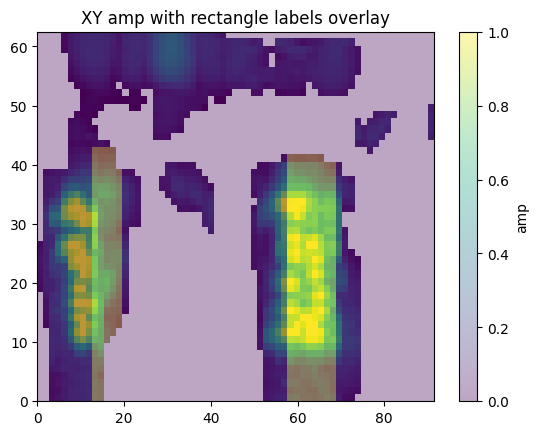

In [ ]:
ny, nx = img.shape  # rows=y, cols=x

labels2d = np.zeros((ny, nx), dtype=np.uint8)

rects = [
    (34.29, 38.1,  3.81, 38.1, 1),
    (66.04, 73.34, 3.81, 38.1, 1),
    # (40.0, 55.0, 20.0, 35.0, 3),
]

def world_to_idx_xy(xmin, xmax, ymin, ymax, origin, vs, nx, ny):
    # Convert world bounds -> voxel index bounds using VOXEL EDGES
    ix0 = int(np.floor((xmin - origin[0]) / vs))
    ix1 = int(np.ceil( (xmax - origin[0]) / vs) - 1)
    iy0 = int(np.floor((ymin - origin[1]) / vs))
    iy1 = int(np.ceil( (ymax - origin[1]) / vs) - 1)

    # Clip to grid
    ix0 = max(0, min(nx - 1, ix0))
    ix1 = max(0, min(nx - 1, ix1))
    iy0 = max(0, min(ny - 1, iy0))
    iy1 = max(0, min(ny - 1, iy1))

    if ix1 < ix0 or iy1 < iy0:
        return None
    return ix0, ix1, iy0, iy1

for (xmin, xmax, ymin, ymax, cls) in rects:
    out = world_to_idx_xy(xmin, xmax, ymin, ymax, origin, vs, nx, ny)
    if out is None:
        continue
    ix0, ix1, iy0, iy1 = out
    labels2d[iy0:iy1+1, ix0:ix1+1] = cls

scanned_mask = np.isfinite(img) 
labels2d_masked = labels2d.copy()
labels2d_masked[~scanned_mask] = 0


print("labels2d shape:", labels2d.shape, "unique:", np.unique(labels2d))

X_MIN, X_MAX = 0.0, 91.5
Y_MIN, Y_MAX = 0.0, 62.5

plt.figure()
plt.imshow(img, origin="lower", extent=[X_MIN, X_MAX, Y_MIN, Y_MAX], aspect="auto")
plt.imshow(labels2d_masked, origin="lower", extent=[X_MIN, X_MAX, Y_MIN, Y_MAX], alpha=0.35, aspect="auto")
plt.xlim(X_MIN, X_MAX); plt.ylim(Y_MIN, Y_MAX)
plt.colorbar(label="amp")
plt.title("XY amp with rectangle labels overlay")
plt.show()

# base = os.path.splitext(os.path.basename(json_path))[0]  # e.g. "scan1.2"
    #
    # if base.lower().startswith("scan"):
    #     label_base = "label" + base[4:]                      # "label1.2"
    # else:
    #     label_base = "label_" + base                         # fallback if name isn't scan*
    #
    # out_path = os.path.join(os.path.dirname(json_path), f"{label_base}.npy")
    # np.save(out_path, labels2d_masked)
    #
    # print("Saved:", out_path, "shape:", labels2d_masked.shape, "unique:", np.unique(labels2d_masked))


In [38]:
import os
import numpy as np

out_dir = r"C:\Users\richa\OneDrive\Documents\College\CreateX\Testing\11-28"
os.makedirs(out_dir, exist_ok=True)

out_path = os.path.join(out_dir, "Scan.npy")
np.save(out_path, labels2d)

Automation per Group

Found 24 files in C:\Users\richa\OneDrive\Documents\College\CreateX\Testing\11-28\GroupD


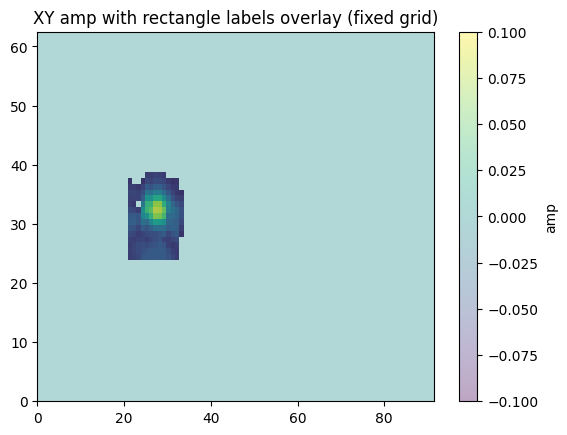

Saved: C:\Users\richa\OneDrive\Documents\College\CreateX\Testing\11-28\GroupD\label2.17.npy shape: (63, 92) unique: [0]


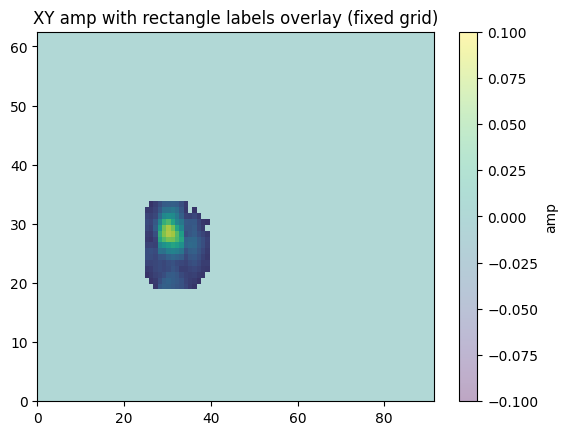

Saved: C:\Users\richa\OneDrive\Documents\College\CreateX\Testing\11-28\GroupD\label2.18.npy shape: (63, 92) unique: [0]


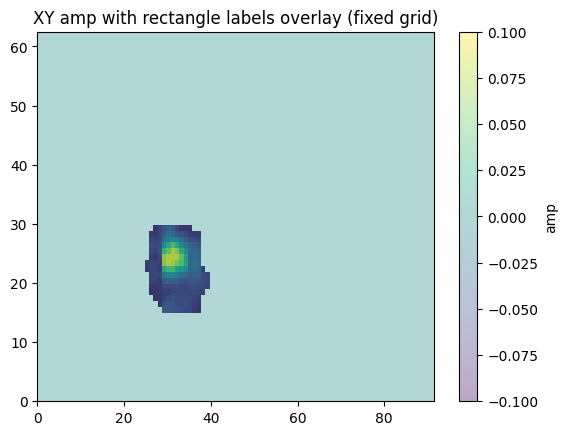

Saved: C:\Users\richa\OneDrive\Documents\College\CreateX\Testing\11-28\GroupD\label2.19.npy shape: (63, 92) unique: [0]


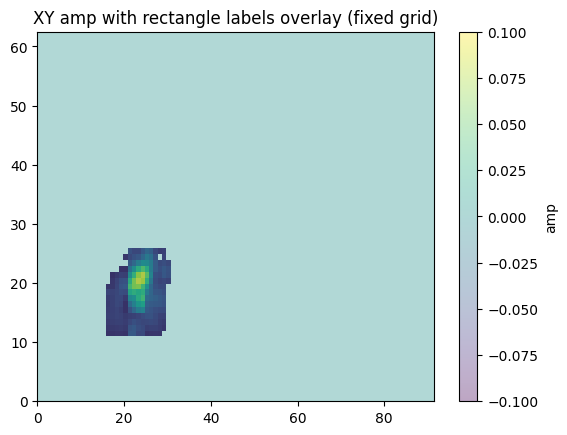

Saved: C:\Users\richa\OneDrive\Documents\College\CreateX\Testing\11-28\GroupD\label2.20.npy shape: (63, 92) unique: [0]


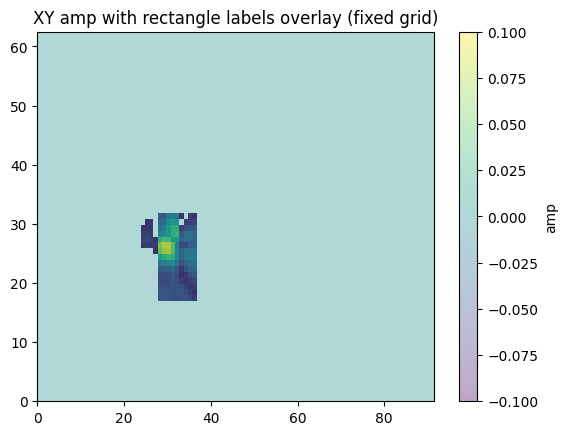

Saved: C:\Users\richa\OneDrive\Documents\College\CreateX\Testing\11-28\GroupD\label2.21.npy shape: (63, 92) unique: [0]


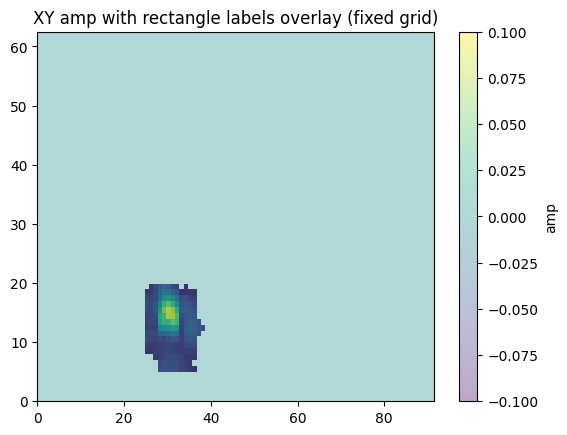

Saved: C:\Users\richa\OneDrive\Documents\College\CreateX\Testing\11-28\GroupD\label2.22.npy shape: (63, 92) unique: [0]


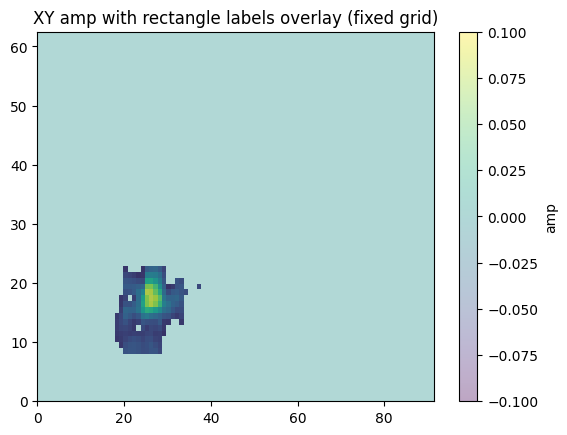

Saved: C:\Users\richa\OneDrive\Documents\College\CreateX\Testing\11-28\GroupD\label2.23.npy shape: (63, 92) unique: [0]


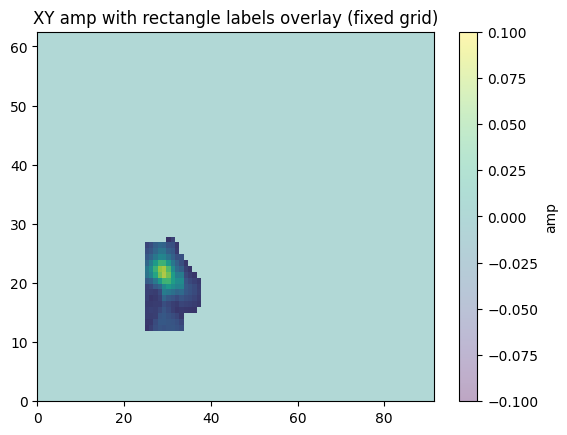

Saved: C:\Users\richa\OneDrive\Documents\College\CreateX\Testing\11-28\GroupD\label2.24.npy shape: (63, 92) unique: [0]


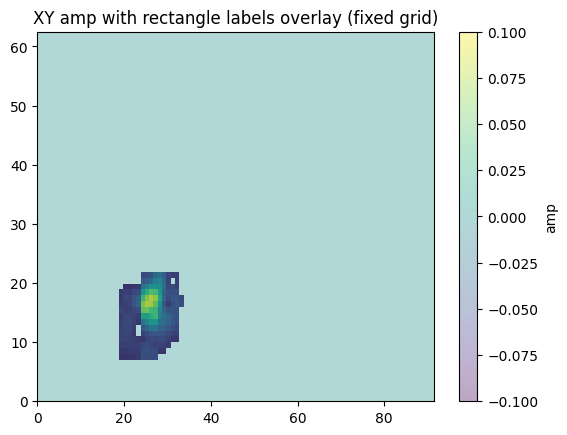

Saved: C:\Users\richa\OneDrive\Documents\College\CreateX\Testing\11-28\GroupD\label2.25.npy shape: (63, 92) unique: [0]


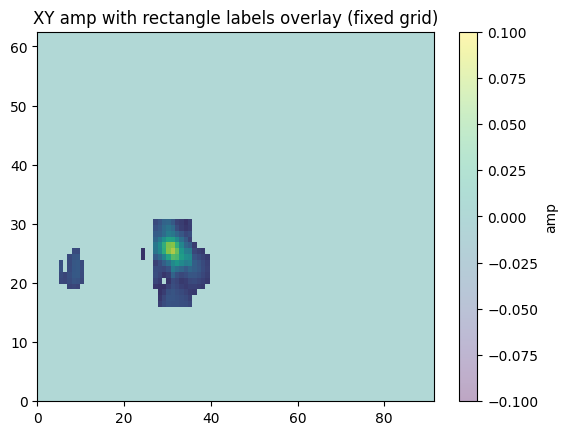

Saved: C:\Users\richa\OneDrive\Documents\College\CreateX\Testing\11-28\GroupD\label2.26.npy shape: (63, 92) unique: [0]


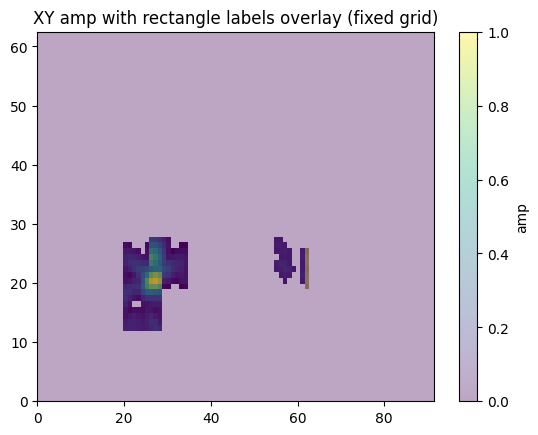

Saved: C:\Users\richa\OneDrive\Documents\College\CreateX\Testing\11-28\GroupD\label2.27.npy shape: (63, 92) unique: [0 1]


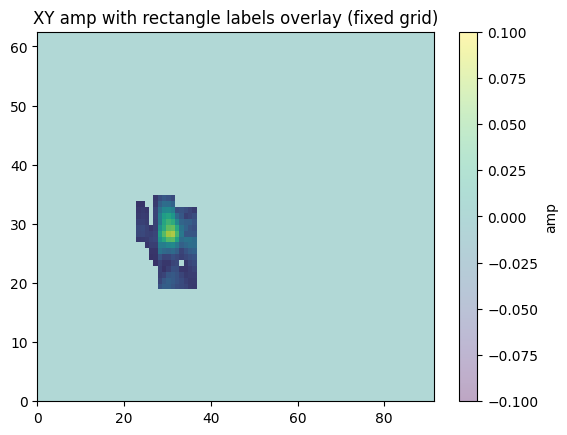

Saved: C:\Users\richa\OneDrive\Documents\College\CreateX\Testing\11-28\GroupD\label2.28.npy shape: (63, 92) unique: [0]


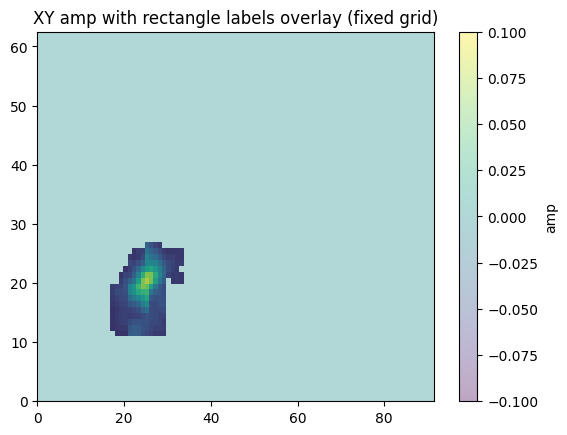

Saved: C:\Users\richa\OneDrive\Documents\College\CreateX\Testing\11-28\GroupD\label2.29.npy shape: (63, 92) unique: [0]


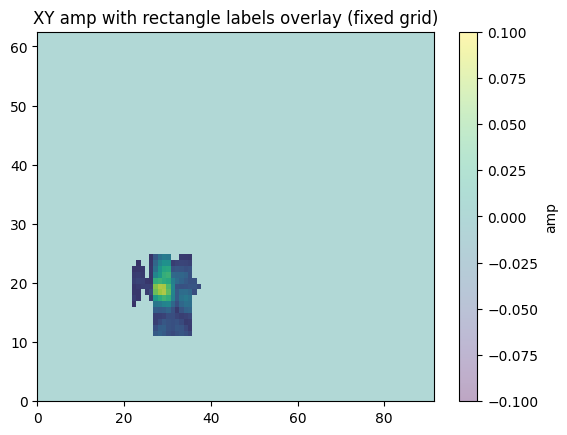

Saved: C:\Users\richa\OneDrive\Documents\College\CreateX\Testing\11-28\GroupD\label2.30.npy shape: (63, 92) unique: [0]


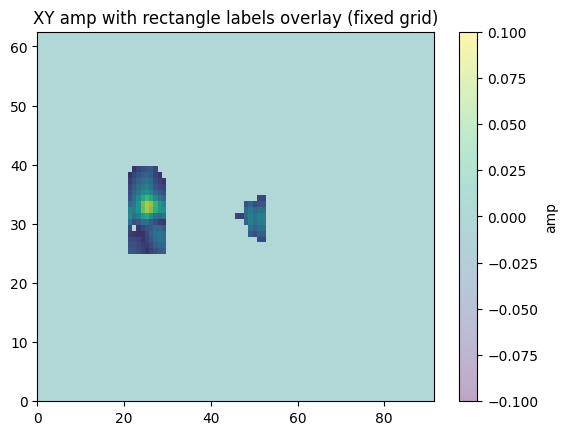

Saved: C:\Users\richa\OneDrive\Documents\College\CreateX\Testing\11-28\GroupD\label2.31.npy shape: (63, 92) unique: [0]


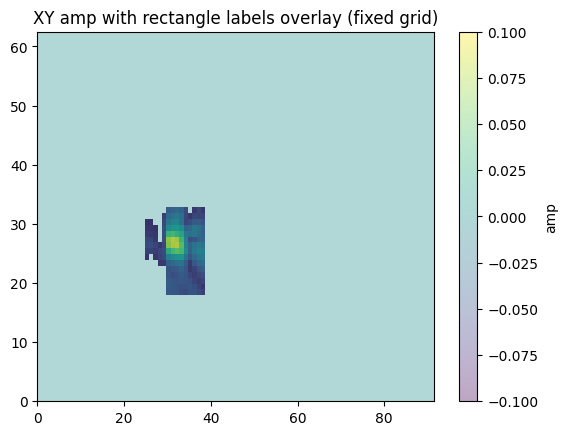

Saved: C:\Users\richa\OneDrive\Documents\College\CreateX\Testing\11-28\GroupD\label2.32.npy shape: (63, 92) unique: [0]


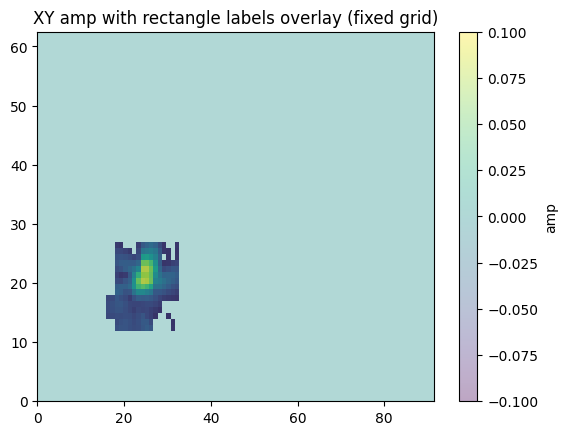

Saved: C:\Users\richa\OneDrive\Documents\College\CreateX\Testing\11-28\GroupD\label2.33.npy shape: (63, 92) unique: [0]


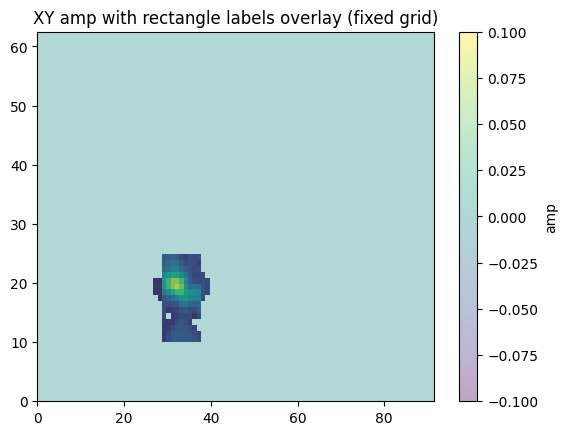

Saved: C:\Users\richa\OneDrive\Documents\College\CreateX\Testing\11-28\GroupD\label2.34.npy shape: (63, 92) unique: [0]


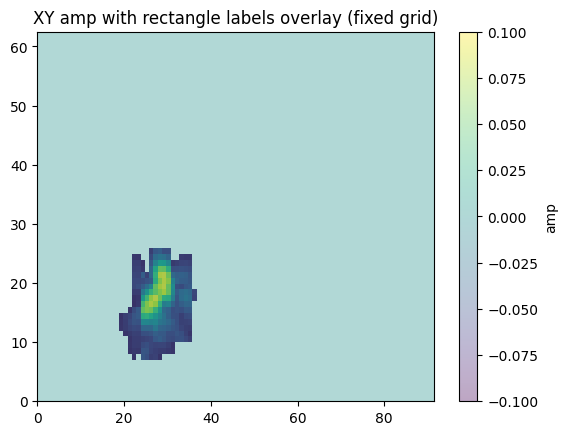

Saved: C:\Users\richa\OneDrive\Documents\College\CreateX\Testing\11-28\GroupD\label2.35.npy shape: (63, 92) unique: [0]


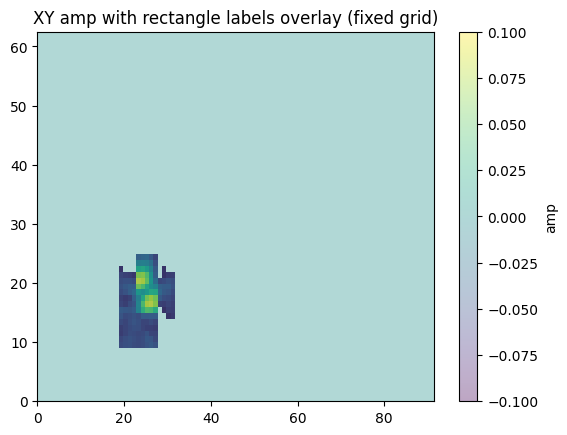

Saved: C:\Users\richa\OneDrive\Documents\College\CreateX\Testing\11-28\GroupD\label2.36.npy shape: (63, 92) unique: [0]


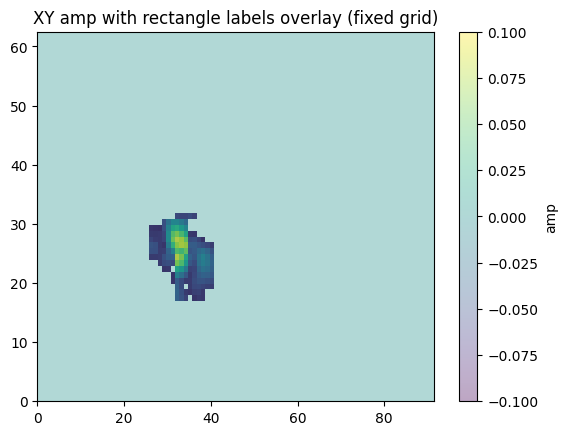

Saved: C:\Users\richa\OneDrive\Documents\College\CreateX\Testing\11-28\GroupD\label2.37.npy shape: (63, 92) unique: [0]


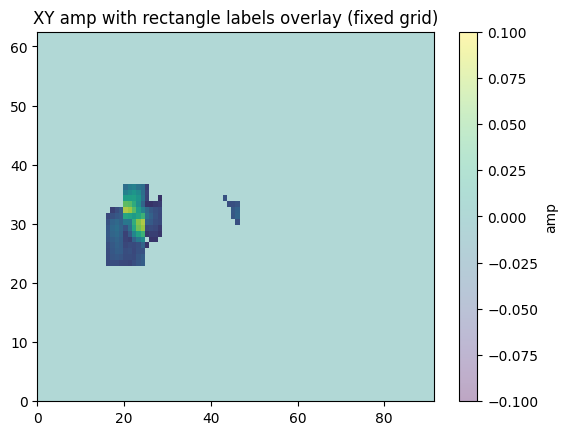

Saved: C:\Users\richa\OneDrive\Documents\College\CreateX\Testing\11-28\GroupD\label2.38.npy shape: (63, 92) unique: [0]


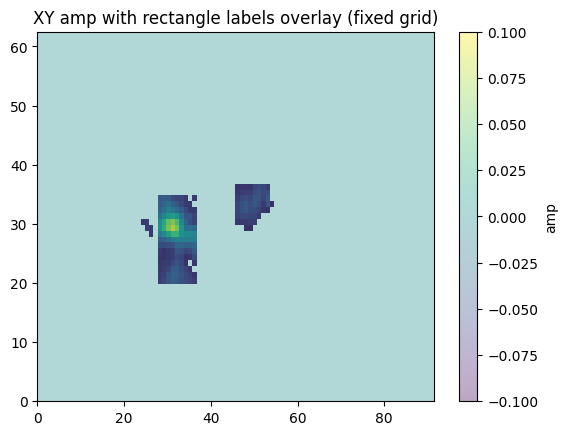

Saved: C:\Users\richa\OneDrive\Documents\College\CreateX\Testing\11-28\GroupD\label2.39.npy shape: (63, 92) unique: [0]


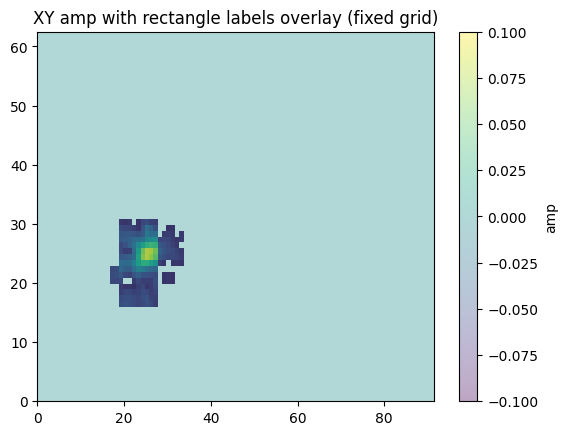

Saved: C:\Users\richa\OneDrive\Documents\College\CreateX\Testing\11-28\GroupD\label2.40.npy shape: (63, 92) unique: [0]


In [17]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
clear_output(wait=True)


# ---- configure ----
GROUP_DIR = r"C:\Users\richa\OneDrive\Documents\College\CreateX\Testing\11-28\GroupD"

# Grab all scans in this folder (adjust pattern if you use .txt, .jsonl, etc.)
paths = sorted(glob.glob(os.path.join(GROUP_DIR, "*.json")))

print(f"Found {len(paths)} files in {GROUP_DIR}")

for json_path in paths:
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    frames = data.get("frames", [])

    xs, ys, zs, amps = [], [], [], []

    TO_GLOBAL = True  # set False to plot raw per-frame (local) point coordinates

    for fr in frames:
        pos = fr.get("position") or {}
        px = float(pos.get("x", 0.0))
        py = float(pos.get("y", 0.0))
        pz = float(pos.get("z", 0.0))  # usually absent

        for p in (fr.get("points") or []):
            x = float(p["x"])
            y = float(p["y"])
            z = float(p["z"])
            a = float(p["amp"])

            if TO_GLOBAL:
                x += px
                y += py
                z += pz

            xs.append(x); ys.append(y); zs.append(z); amps.append(a)

    xs = np.asarray(xs, dtype=np.float32)
    ys = np.asarray(ys, dtype=np.float32)
    zs = np.asarray(zs, dtype=np.float32)
    amps = np.asarray(amps, dtype=np.float32)

    z_min, z_max = -12.7, 0.0   # keep points with -12.7 <= z <= 0

    mask = (zs >= z_min) & (zs <= z_max)
    xs, ys, zs, amps = xs[mask], ys[mask], zs[mask], amps[mask]

    vout = voxelize_xyzamp(xs, ys, zs, amps, voxel_size_cm=1, agg="max")
    vox = vout[1]

    v_idx = vox["idx"]         # (M,3) voxel indices
    v_amp = vox["amp"]         # (M,) aggregated amplitude
    origin = vox["origin"]     # (3,)
    vs = vox["voxel_size_cm"]  # scalar

    # Convert voxel indices -> voxel CENTER coordinates for plotting
    vx = origin[0] + (v_idx[:, 0].astype(np.float32) + 0.5) * vs
    vy = origin[1] + (v_idx[:, 1].astype(np.float32) + 0.5) * vs
    vz = origin[2] + (v_idx[:, 2].astype(np.float32) + 0.5) * vs

    # # --- 2) 3D scatter plot (color by amplitude) ---
    # fig = plt.figure()
    # ax = fig.add_subplot(111, projection="3d")
    # sc = ax.scatter(vx, vy, vz, s=6, c=v_amp)  # no explicit colors specified
    # fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.1, label="amp")

    # # fig = plt.figure()
    # # ax = fig.add_subplot(111, projection="3d")
    # # sc = ax.scatter(xs, ys, zs, s=1, c=amps)  # no explicit colors specified
    # # fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.1, label="amp")

    # ax.set_xlabel("X")
    # ax.set_ylabel("Y")
    # ax.set_zlabel("Z")
    # ax.set_xlim(0.0, 91.5)
    # ax.set_ylim(0.0, 62.5)
    # ax.set_title(f"3D point cloud ({'global' if TO_GLOBAL else 'local'})")

    # plt.show()

    # -------------------- FIXED WALL GRID CONSTANTS --------------------
    X_MIN, X_MAX = 0.0, 91.5
    Y_MIN, Y_MAX = 0.0, 62.5

    vs_fixed = float(vox["voxel_size_cm"])  # keep consistent with voxelize_xyzamp(... voxel_size_cm=1)
    nx_fixed = int(np.ceil((X_MAX - X_MIN) / vs_fixed))
    ny_fixed = int(np.ceil((Y_MAX - Y_MIN) / vs_fixed))

    # -------------------- RASTERIZE TO FIXED GRID (MAX AMP) --------------------
    img = np.full((ny_fixed, nx_fixed), -np.inf, dtype=np.float32)  # NOT NaN

    ixf = np.floor((vx - X_MIN) / vs_fixed).astype(np.int32)
    iyf = np.floor((vy - Y_MIN) / vs_fixed).astype(np.int32)

    valid = (ixf >= 0) & (ixf < nx_fixed) & (iyf >= 0) & (iyf < ny_fixed)
    np.maximum.at(img, (iyf[valid], ixf[valid]), v_amp[valid])

    img[~np.isfinite(img)] = np.nan  # unscanned -> NaN (for mask/plot)

    # -------------------- LABELS ON THE SAME FIXED GRID --------------------
    labels2d = np.zeros((ny_fixed, nx_fixed), dtype=np.uint8)

    rects = [
        # (24.13, 27.94,  3.81, 38.1, 1),
        (62.23, 69.85,  3.81, 38.1, 1),
    ]
    saveQuest = True

    def world_to_idx_xy_fixed(xmin, xmax, ymin, ymax, X_MIN, Y_MIN, vs, nx, ny):
        ix0 = int(np.floor((xmin - X_MIN) / vs))
        ix1 = int(np.ceil( (xmax - X_MIN) / vs) - 1)
        iy0 = int(np.floor((ymin - Y_MIN) / vs))
        iy1 = int(np.ceil( (ymax - Y_MIN) / vs) - 1)

        ix0 = max(0, min(nx - 1, ix0)); ix1 = max(0, min(nx - 1, ix1))
        iy0 = max(0, min(ny - 1, iy0)); iy1 = max(0, min(ny - 1, iy1))
        if ix1 < ix0 or iy1 < iy0:
            return None
        return ix0, ix1, iy0, iy1

    for (xmin, xmax, ymin, ymax, cls) in rects:
        out = world_to_idx_xy_fixed(xmin, xmax, ymin, ymax, X_MIN, Y_MIN, vs_fixed, nx_fixed, ny_fixed)
        if out is None:
            continue
        ix0, ix1, iy0, iy1 = out
        labels2d[iy0:iy1+1, ix0:ix1+1] = cls

    # Mask labels using the FIXED img
    scanned_mask = np.isfinite(img)
    labels2d_masked = labels2d.copy()
    labels2d_masked[~scanned_mask] = 0

    # -------------------- PLOT --------------------
    plt.figure()
    plt.imshow(img, origin="lower", extent=[X_MIN, X_MAX, Y_MIN, Y_MAX], aspect="auto")
    plt.imshow(labels2d_masked, origin="lower", extent=[X_MIN, X_MAX, Y_MIN, Y_MAX], alpha=0.35, aspect="auto")
    plt.xlim(X_MIN, X_MAX); plt.ylim(Y_MIN, Y_MAX)
    plt.colorbar(label="amp")
    plt.title("XY amp with rectangle labels overlay (fixed grid)")
    plt.show()

    if saveQuest:
        base = os.path.splitext(os.path.basename(json_path))[0]  # e.g. "scan1.2"
        
        if base.lower().startswith("scan"):
            label_base = "label" + base[4:]                      # "label1.2"
        else:
            label_base = "label_" + base                         # fallback if name isn't scan*
        
        out_path = os.path.join(os.path.dirname(json_path), f"{label_base}.npy")
        np.save(out_path, labels2d_masked)
        
        print("Saved:", out_path, "shape:", labels2d_masked.shape, "unique:", np.unique(labels2d_masked))

Evaluation

In [4]:
import os
import numpy as np
import torch
import glob

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = r"C:\Users\richa\OneDrive\Documents\College\CreateX\Testing\TrainingDataAndLabel"
testSplit = 0.2

def train_val_split(scene_pairs, val_fraction=testSplit, seed=0):
    scene_pairs = list(scene_pairs)
    rng = np.random.RandomState(seed)
    rng.shuffle(scene_pairs)
    n_total = len(scene_pairs)
    n_val = max(1, int(np.round(n_total * testSplit)))
    val_pairs = scene_pairs[:n_val]
    train_pairs = scene_pairs[n_val:]
    if not train_pairs:  # fallback: at least one train
        train_pairs = val_pairs
    return train_pairs, val_pairs

def list_scene_files(data_dir):
    """
    Find all feature-label pairs in DATA_DIR.

    Assumes naming like:
        <scene_id>.rawVox_2ch.npy
        <scene_id>.labels.npy
    """
    feature_files = glob.glob(os.path.join(data_dir, "*.2chVox.npy"))
    scene_pairs = []

    for fpath in feature_files:
        base = os.path.basename(fpath)
        scene_id = base.replace(".2chVox.npy", "")
        label_path = os.path.join(data_dir, f"{scene_id}.labels.npy")
        if os.path.exists(label_path):
            scene_pairs.append((fpath, label_path))
        else:
            print(f"[WARN] Label file missing for {fpath}, skipping.")

    if not scene_pairs:
        raise RuntimeError(f"No scene pairs found in {data_dir}")

    return scene_pairs

print(f"Using device: {DEVICE}")

    # Ensure directory exists and is writable
os.makedirs(DATA_DIR, exist_ok=True)
if not os.access(DATA_DIR, os.W_OK):
    raise RuntimeError(f"DATA_DIR not writable: {DATA_DIR}")

# 1) discover scenes
scene_pairs = list_scene_files(DATA_DIR)
print(f"Found {len(scene_pairs)} scenes.")

# 2) split train/val
train_pairs, val_pairs = train_val_split(scene_pairs, val_fraction=testSplit)
print(val_pairs)



Using device: cuda
Found 19 scenes.
[('C:\\Users\\richa\\OneDrive\\Documents\\College\\CreateX\\Testing\\TrainingDataAndLabel\\2.21.2chVox.npy', 'C:\\Users\\richa\\OneDrive\\Documents\\College\\CreateX\\Testing\\TrainingDataAndLabel\\2.21.labels.npy'), ('C:\\Users\\richa\\OneDrive\\Documents\\College\\CreateX\\Testing\\TrainingDataAndLabel\\2.13.2chVox.npy', 'C:\\Users\\richa\\OneDrive\\Documents\\College\\CreateX\\Testing\\TrainingDataAndLabel\\2.13.labels.npy'), ('C:\\Users\\richa\\OneDrive\\Documents\\College\\CreateX\\Testing\\TrainingDataAndLabel\\2.2.2chVox.npy', 'C:\\Users\\richa\\OneDrive\\Documents\\College\\CreateX\\Testing\\TrainingDataAndLabel\\2.2.labels.npy'), ('C:\\Users\\richa\\OneDrive\\Documents\\College\\CreateX\\Testing\\TrainingDataAndLabel\\2.4.2chVox.npy', 'C:\\Users\\richa\\OneDrive\\Documents\\College\\CreateX\\Testing\\TrainingDataAndLabel\\2.4.labels.npy')]


Using device: cpu
Loaded volume shape: (2, 81, 244, 366)
Using Y indices: [100, 122, 180]


C:\Users\richa\AppData\Local\Temp\ipykernel_520\1738879973.py:85: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(pt_path, map_location=device)


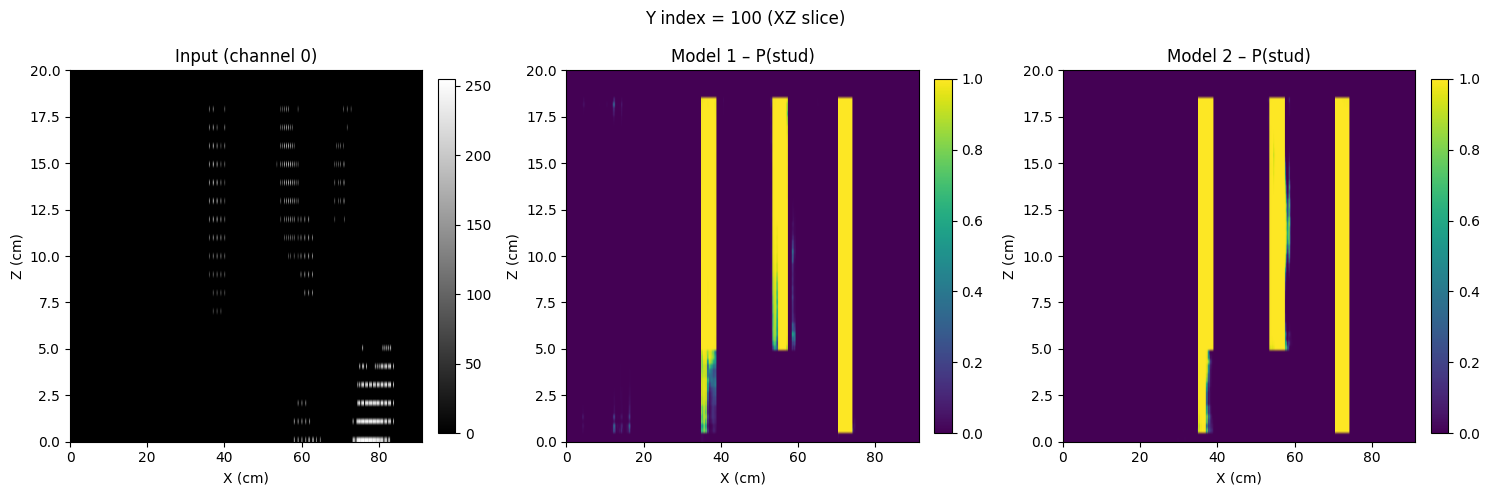

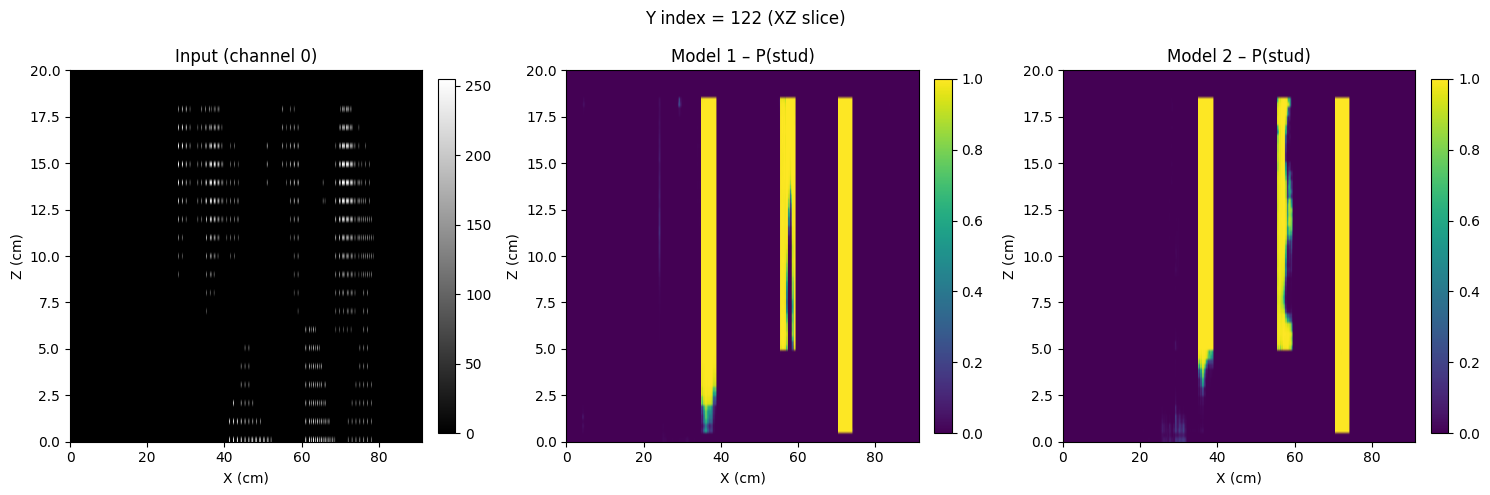

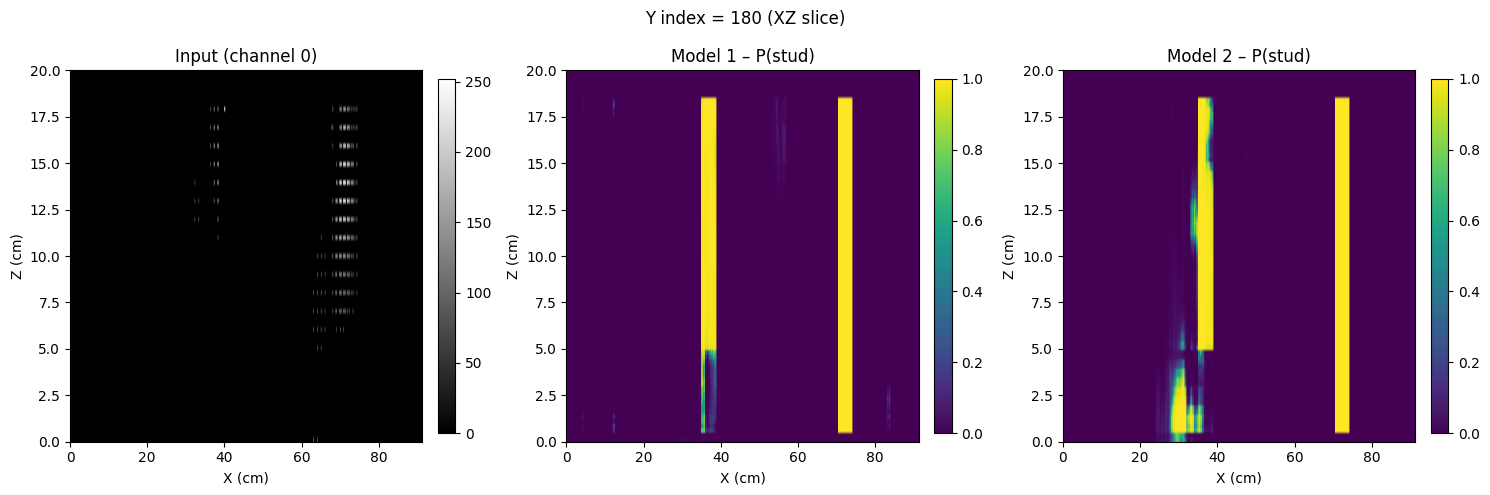

In [8]:
import os
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from two_d_NN import StudUNet

# =========================================================
# Globals
# =========================================================
device = torch.device("cpu") #torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

IN_CHANNELS = 2          # you trained with 2 input channels
NUM_CLASSES = 2          # background + stud (matches checkpoint outc.weight [2, ...])


# =========================================================
# 3D scatter helper (optional)
# =========================================================
def plot_eval(prob_grid, threshold=0.0):
    """
    prob_grid: (nz, ny, nx) array of probabilities in [0, 1]
    threshold: only show points with prob >= threshold
    """
    nz, ny, nx = prob_grid.shape

    zs = np.arange(nz)
    ys = np.arange(ny)
    xs = np.arange(nx)

    Z, Y, X = np.meshgrid(zs, ys, xs, indexing="ij")  # (nz, ny, nx)

    Xf = X.ravel()
    Yf = Y.ravel()
    Zf = Z.ravel()
    Pf = prob_grid.ravel()

    mask = Pf >= threshold

    Xp = Xf[mask]
    Yp = Yf[mask]
    Zp = Zf[mask]
    Pp = Pf[mask]

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")

    sc = ax.scatter(
        Xp, Yp, Zp,
        c=Pp,
        s=5,
        cmap="inferno",
        alpha=0.9
    )

    fig.colorbar(sc, ax=ax, label="Stud Probability")

    ax.set_title("Predicted Stud Probability Cloud")
    ax.set_xlabel("X (voxel)")
    ax.set_ylabel("Y (voxel)")
    ax.set_zlabel("Z (voxel)")

    plt.show()


# =========================================================
# Model loading
# =========================================================
def load_unet_model(pt_path, in_channels=IN_CHANNELS, num_classes=NUM_CLASSES):
    """
    Load a StudUNet from a .pt checkpoint.

    Assumes your .pt file is either:
      - dict with key 'model_state_dict', OR
      - bare state_dict.

    If instead you did torch.save(model, path), replace the body with:
        model = torch.load(pt_path, map_location=device)
        model.eval()
        return model
    """
    # You can add weights_only=True once you’re sure checkpoints are pure weights.
    checkpoint = torch.load(pt_path, map_location=device)

    model = StudUNet(in_channels=in_channels, num_classes=num_classes)

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"])
    else:
        # bare state_dict
        model.load_state_dict(checkpoint)

    model.to(device)
    model.eval()
    return model


# =========================================================
# Normalization (same as training)
# =========================================================
CHANNEL_MEAN = np.array([1.0672636, 1.0245], dtype=np.float32)
CHANNEL_STD  = np.array([12.563799, 12.002741], dtype=np.float32)

def normalize_channels(slice_czhw: np.ndarray) -> np.ndarray:
    """
    slice_czhw: numpy array of shape (C, H, W)
    applies (x - mean) / std per channel.
    """
    return (slice_czhw - CHANNEL_MEAN[:, None, None]) / CHANNEL_STD[:, None, None]


# =========================================================
# Run both models on one XZ slice (2-class output)
# =========================================================
def run_models_on_slice(xz_slice_czhw: np.ndarray, model1, model2):
    """
    xz_slice_czhw: np.array (C, H, W), already normalized.
    Returns two probability maps (H, W) for the "stud" class (class index 1).
    """
    inp = torch.from_numpy(xz_slice_czhw).unsqueeze(0).float().to(device)  # (1, C, H, W)

    with torch.no_grad():
        logits1 = model1(inp)  # (1, 2, H, W)
        logits2 = model2(inp)  # (1, 2, H, W)

        # 2-class output: channel 0 = background, channel 1 = stud
        prob1 = torch.softmax(logits1, dim=1)[:, 1]  # (1, H, W)
        prob2 = torch.softmax(logits2, dim=1)[:, 1]  # (1, H, W)

    prob1_np = prob1.squeeze(0).cpu().numpy()  # (H, W)
    prob2_np = prob2.squeeze(0).cpu().numpy()
    return prob1_np, prob2_np


# =========================================================
# Visualization on a volume
# =========================================================
def visualize_models_on_volume(
    volume_path: str,
    model1_path: str,
    model2_path: str,
    y_indices=None,
    in_channels: int = IN_CHANNELS,
):
    """
    volume_path: path to .npy file with shape (C, Z, Y, X)
    y_indices: list of Y indices to visualize. If None, pick a few automatically.
    """
    # ---------- Load data ----------
    vol = np.load(volume_path)  # (C, Z, Y, X)
    print("Loaded volume shape:", vol.shape)
    assert vol.ndim == 4, f"Expected (C, Z, Y, X), got {vol.shape}"
    C, Z, Y, X = vol.shape
    if C != in_channels:
        raise ValueError(f"Expected {in_channels} channels, got {C}")
    voxel_size = 0.25  # cm, same used in voxelizer
    xs_cm = np.arange(X) * voxel_size
    zs_cm = np.arange(Z) * voxel_size
        


    if y_indices is None:
        y_indices = [Y // 4, Y // 2, 3 * Y // 4]
    print("Using Y indices:", y_indices)

    # ---------- Load models ----------
    model1 = load_unet_model(model1_path, in_channels=in_channels, num_classes=NUM_CLASSES)
    model2 = load_unet_model(model2_path, in_channels=in_channels, num_classes=NUM_CLASSES)

    # ---------- For each Y index, extract XZ slice and run models ----------
    for y_idx in y_indices:
        if not (0 <= y_idx < Y):
            print(f"Skipping invalid y_idx={y_idx}")
            continue

        # XZ slice at fixed Y: (C, Z, X)
        xz_slice = vol[:, :, y_idx, :]

        # Normalize per channel
        xz_slice_norm = normalize_channels(xz_slice)

        # Run both models
        prob1, prob2 = run_models_on_slice(xz_slice_norm, model1, model2)

        # For visualization of the input, pick one channel (e.g. channel 0)
        input_img = xz_slice[0]  # (Z, X)

        # ---------- Plot ----------
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        fig.suptitle(f"Y index = {y_idx} (XZ slice)")

        input_img = xz_slice[0]  # (Z, X)

        # ---- USE CM AXES (REPLACE imshow) ----
        im0 = axes[0].imshow(
            input_img,
            extent=[xs_cm[0], xs_cm[-1], zs_cm[0], zs_cm[-1]],
            aspect="auto",
            cmap="gray",
            origin="lower"
        )
        # --------------------------------------
        axes[0].set_title("Input (channel 0)")
        plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

        im1 = axes[1].imshow(
            prob1,
            extent=[xs_cm[0], xs_cm[-1], zs_cm[0], zs_cm[-1]],
            aspect="auto",
            cmap="viridis",
            vmin=0.0,
            vmax=1.0,
            origin="lower"
        )
        axes[1].set_title("Model 1 – P(stud)")
        plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

        im2 = axes[2].imshow(
            prob2,
            extent=[xs_cm[0], xs_cm[-1], zs_cm[0], zs_cm[-1]],
            aspect="auto",
            cmap="viridis",
            vmin=0.0,
            vmax=1.0,
            origin="lower"
        )
        axes[2].set_title("Model 2 – P(stud)")
        plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

        for ax in axes:
            ax.set_xlabel("X (cm)")
            ax.set_ylabel("Z (cm)")

        plt.tight_layout()
        plt.show()


# =========================================================
# Example usage
# =========================================================
if __name__ == "__main__":
    # Volume: 2-channel voxel data, shape (2, Z, Y, X)
    volume_path = (
        r"C:\Users\richa\OneDrive\Documents\College\CreateX\Testing"
        r"\TrainingDataAndLabel\2.13.2chVox.npy"
    )

    # Models (paths consistent with what you just ran)
    model1_path = (
        r"C:\Users\richa\OneDrive\Documents\College\CreateX\Testing"
        r"\xz_slice_unet_best.pt"
    )
    model2_path = (
        r"C:\Users\richa\OneDrive\Documents\College\CreateX\Testing"
        r"\xz_slice_unet_final.pt"
    )

    # Y indices you want to visualize (must be < 244 for your volume)
    y_indices = [100, 122, 180]

    visualize_models_on_volume(
        volume_path=volume_path,
        model1_path=model1_path,
        model2_path=model2_path,
        y_indices=y_indices,
        in_channels=IN_CHANNELS,
    )
